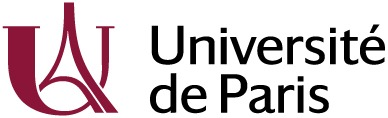
## M2 VMI : Semantic segmentation using CNNs on remote sensing images

You can get the data from my [Google Drive](https://drive.google.com/drive/folders/1Tr3q8kjPDzoamNFuHv7vTBsj5-acJC7Z?usp=sharing).

# Remote Sensing Semantic Segmentation

Semantic segmentation of high-resolution aerial images using a Hypercolumns-based Convolutional Neural Network (CNN).

This project implements a complete pixel-level classification pipeline using the **ISPRS Vaihingen dataset** and **PyTorch**.

The objective is to assign a semantic class to every pixel of an aerial image and distinguish different categories of urban environments.

### Key Results

- **Pixel Accuracy:** 70.88%
- **Mean IoU:** 38.71%
- **Model:** Hypercolumns-based CNN
- **Dataset:** ISPRS Vaihingen
- **Framework:** PyTorch

### Project Pipeline

```text
Aerial Image
     │
     ▼
512 × 512 Image Patches
     │
     ▼
Hypercolumns CNN
     │
     ▼
Pixel-wise Classification
     │
     ▼
Semantic Segmentation Map
     │
     ▼
Evaluation

## 2. Problem Definition

Semantic segmentation is a pixel-level classification task.

Unlike image classification, where a single label is assigned to an entire image, semantic segmentation assigns a class to **every pixel** of the input image.

In this project, the model takes a high-resolution aerial image as input and predicts a semantic label for each pixel.

The input imagery uses **Near Infrared (NIR), Red, and Green (RGB-like) channels**, while the ground truth contains six semantic classes.

### Semantic Classes

The Vaihingen dataset contains six semantic classes:

| Class | Name | RGB Label |
|---|---|---|
| 0 | Impervious surfaces | (255, 255, 255) |
| 1 | Building | (0, 0, 255) |
| 2 | Low vegetation | (0, 255, 255) |
| 3 | Tree | (0, 255, 0) |
| 4 | Car | (255, 255, 0) |
| 5 | Clutter / Background | (255, 0, 0) |

### Segmentation Objective

The objective can be represented as:

```text
Aerial Image
     │
     ▼
   CNN Model
     │
     ▼
Pixel-wise Predictions
     │
     ▼
Semantic Segmentation Map

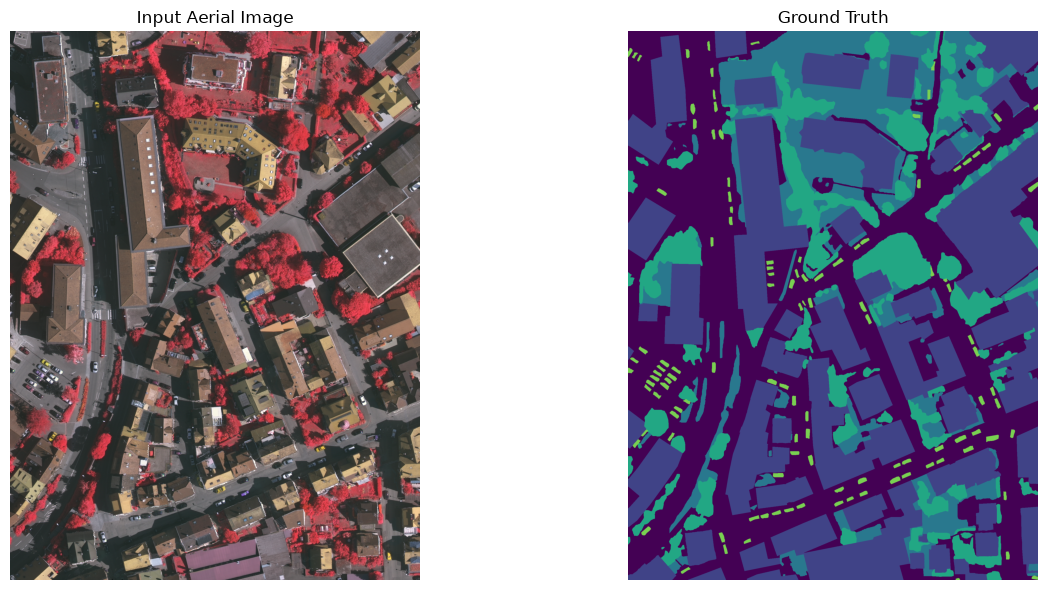

In [ ]:
import os
import matplotlib.pyplot as plt
from skimage import io

tile = "top_mosaic_09cm_area1.tif"

image_path = os.path.join("..", "data", "top", tile)
gt_path = os.path.join("..", "data", "1CGT", tile)

image = io.imread(image_path)
ground_truth = io.imread(gt_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image)
axes[0].set_title("Input Aerial Image")
axes[0].axis("off")

axes[1].imshow(ground_truth)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

The ground-truth map provides the reference segmentation that the CNN learns to reproduce.

The task is therefore to learn a mapping:

**Input image → semantic class for each pixel**

## 3. Dataset

The project uses the **ISPRS Vaihingen dataset**, which contains high-resolution aerial images of urban areas.

The dataset provides aerial image tiles together with corresponding ground-truth semantic segmentation maps.

Each pixel in the ground truth is associated with one of the six semantic classes introduced in the previous section.

### Dataset Split

The image tiles are divided into three subsets:

| Split | Area IDs |
|---|---|
| Training | 1, 3, 5, 7, 11, 13, 15, 17, 21, 23, 26 |
| Validation | 28, 30, 32, 34, 37 |
| Test | 2, 4, 6, 8, 10, 12, 14, 16, 20, 22, 24, 27, 29, 31, 33, 35, 38 |

The training set is used to optimize the model parameters, the validation set is used to monitor the learning process, and the test set is reserved for the final evaluation.

### Patch Extraction

The original aerial images are large, so they are divided into smaller **512 × 512 patches** before being used by the CNN.

A **50% overlap** is used between neighboring patches. This increases the number of training samples and provides overlapping spatial context around object boundaries.

The image and its corresponding ground-truth map are always cropped using the same spatial coordinates to preserve pixel-level correspondence.

                 Large Aerial Image
                         │
                         ▼
        ┌─────────────────────────────┐
        │                             │
        │        Input Image          │
        │                             │
        └─────────────────────────────┘
                         │
                         ▼
              Patch Extraction
                         │
              ┌──────────┴──────────┐
              ▼                     ▼
      ┌───────────────┐     ┌───────────────┐
      │   Patch 1     │     │   Patch 2     │
      │   512 × 512   │     │   512 × 512   │
      └───────────────┘     └───────────────┘
              │                     │
              └──── 50% overlap ────┘
                         │
                         ▼
                  CNN Input
                   512 × 512

### PyTorch Dataset

A custom `Dataset` class is used to:

1. Load the aerial images and ground-truth maps.
2. Normalize the input images to the `[0, 1]` range.
3. Extract `512 × 512` patches.
4. Convert the image patches to PyTorch tensors.
5. Return paired image and ground-truth patches.

In [ ]:
import os
import numpy as np
import torch
import torchvision.transforms as T

from skimage import io
from torch.utils.data import Dataset


split_imgs = {
    "train": [1, 3, 5, 7, 11, 13, 15, 17, 21, 23, 26],
    "val": [28, 30, 32, 34, 37],
    "test": [2, 4, 6, 8, 10, 12, 14, 16, 20, 22, 24, 27, 29, 31, 33, 35, 38],
}


class VaihingenDataset(Dataset):

    def __init__(self, img_folder, GT_folder, split, patch_size=512):

        self.imgs = []
        self.GTs = []

        conversion = T.ToTensor()
        overlap = patch_size // 2

        for img_index in split_imgs[split]:

            img_path = os.path.join(
                img_folder,
                f"top_mosaic_09cm_area{img_index}.tif"
            )

            gt_path = os.path.join(
                GT_folder,
                f"top_mosaic_09cm_area{img_index}.tif"
            )

            img = io.imread(img_path) / 255
            GT = io.imread(gt_path)

            for i in np.arange(
                patch_size // 2,
                img.shape[0] - patch_size // 2,
                overlap
            ):

                for j in np.arange(
                    patch_size // 2,
                    img.shape[1] - patch_size // 2,
                    overlap
                ):

                    self.imgs.append(
                        conversion(
                            img[
                                i - patch_size // 2 : i + patch_size // 2,
                                j - patch_size // 2 : j + patch_size // 2,
                                :
                            ]
                        )
                    )

                    self.GTs.append(
                        GT[
                            i - patch_size // 2 : i + patch_size // 2,
                            j - patch_size // 2 : j + patch_size // 2
                        ]
                    )

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):

        img = self.imgs[idx].float()
        GT = self.GTs[idx]

        return img, torch.from_numpy(GT)

### DataLoader

PyTorch `DataLoader` objects are used to load the training and validation patches in batches.

The training data are shuffled, while the validation data keep a fixed order.

In [ ]:
batch_size = 3

training_dataset = VaihingenDataset(
    img_folder="../data/top",
    GT_folder="../data/1CGT",
    split="train"
)

validation_dataset = VaihingenDataset(
    img_folder="../data/top",
    GT_folder="../data/1CGT",
    split="val"
)

train_loader = torch.utils.data.DataLoader(
    training_dataset,
    batch_size=batch_size,
    shuffle=True
)

validate_loader = torch.utils.data.DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training patches:", len(training_dataset))
print("Validation patches:", len(validation_dataset))

Training patches: 576
Validation patches: 224


### Test Set

The test set is kept separate from the training process.

It is not used to optimize the model parameters or monitor training. Instead, the test images are processed during the final evaluation stage to measure the model's performance on unseen data.

## 4. Data Preparation

Before training the CNN, the aerial images need to be prepared in a format suitable for PyTorch.

The preprocessing consists of:

1. Normalizing the input images to the `[0, 1]` range.
2. Extracting fixed-size `512 × 512` patches.
3. Converting the image patches into PyTorch tensors.
4. Keeping the ground-truth labels aligned with the corresponding image patches.

### Input Normalization

The original image pixel values are divided by **255** to normalize them to the `[0, 1]` range.

The ground-truth segmentation maps are not normalized because their values represent semantic class labels.

### Patch Extraction

The original aerial images are too large to be processed directly by the CNN.

Each image is therefore divided into fixed-size patches of:

**512 × 512 pixels**

Neighboring patches are extracted with a **50% overlap**, corresponding to a stride of 256 pixels.

The same coordinates are used for the image and the ground-truth map, ensuring pixel-level correspondence.

                Large Aerial Image
                        │
                        ▼
                 Patch Extraction
                        │
          ┌─────────────┴─────────────┐
          ▼                           ▼
    ┌───────────────┐         ┌───────────────┐
    │    Patch 1    │         │    Patch 2    │
    │   512 × 512   │         │   512 × 512   │
    └───────────────┘         └───────────────┘
          │                           │
          └──────── 50% overlap ─────┘
                        │
                        ▼
                 CNN Input
                  512 × 512

### Conversion to PyTorch Tensors

After cropping, each image patch is converted from a NumPy array to a PyTorch tensor using `torchvision.transforms.ToTensor()`.

The channel order is converted from:

**Height × Width × Channels**

to:

**Channels × Height × Width**

which is the format expected by a PyTorch convolutional network.

```text
NumPy image patch
      |
      |  H × W × C
      v
  ToTensor()
      |
      v
PyTorch tensor
      |
      |  C × H × W
      v
     CNN
```

In [ ]:
# Inspect one training sample

image_patch, ground_truth_patch = training_dataset[0]

print("Image shape:", image_patch.shape)
print("Ground-truth shape:", ground_truth_patch.shape)
print("Image range:", image_patch.min().item(), "to", image_patch.max().item())

Image shape: torch.Size([3, 512, 512])
Ground-truth shape: torch.Size([512, 512])
Image range: 0.09803921729326248 to 1.0


The resulting training sample therefore contains:

- **Input:** `3 × 512 × 512`
- **Ground truth:** `512 × 512`
- **Input range:** `[0, 1]`

The ground-truth map contains one class index for each pixel.

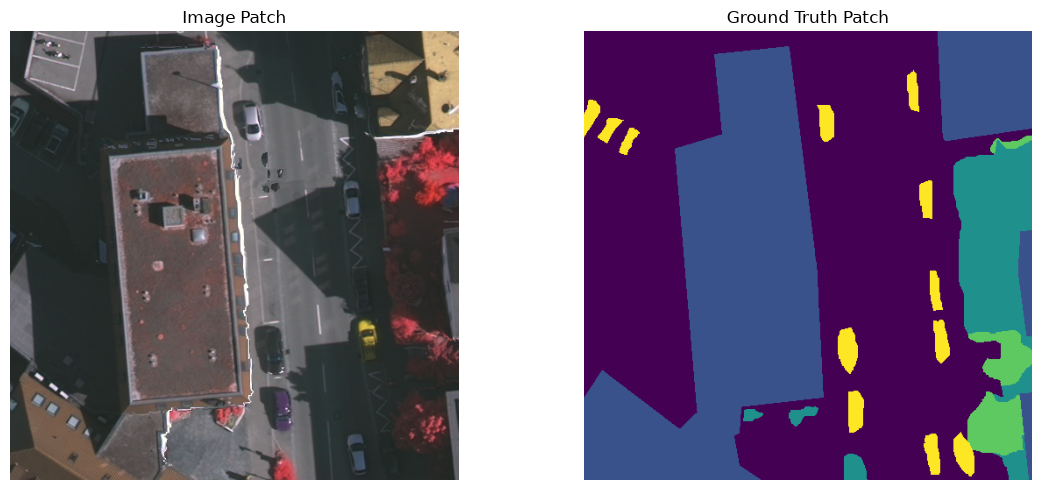

In [ ]:
import matplotlib.pyplot as plt

image_patch, ground_truth_patch = training_dataset[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_patch.permute(1, 2, 0))
plt.title("Image Patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ground_truth_patch)
plt.title("Ground Truth Patch")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Hypercolumns CNN Architecture

The model is a convolutional neural network based on the **Hypercolumns** concept.

Instead of using only the deepest feature representation, the network combines feature maps extracted at different depths.

This allows the model to combine:

- low-level spatial information from shallow layers,
- higher-level semantic information from deeper layers,
- and the original input image.

All feature maps are upsampled to the original spatial resolution and concatenated to form a **hypercolumn representation** for each pixel.

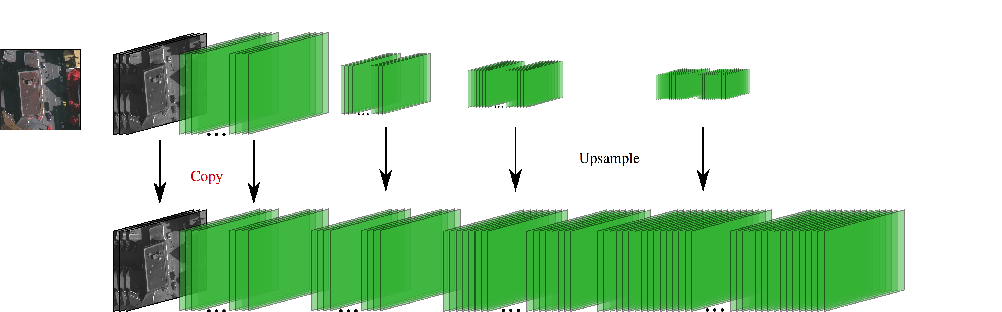

### Network Architecture

| Stage | Operation | Output Shape |
|---|---|---|
| Input | RGB image | `3 × 512 × 512` |
| Conv 1 | `Conv2d(3, 64, 7)` + Tanh | `64 × 506 × 506` |
| Pool 1 | `MaxPool2d(3)` | `64 × 168 × 168` |
| Conv 2 | `Conv2d(64, 64, 5)` + Tanh | `64 × 164 × 164` |
| Pool 2 | `MaxPool2d(3)` | `64 × 54 × 54` |
| Conv 3 | `Conv2d(64, 128, 5)` + Tanh | `128 × 50 × 50` |
| Pool 3 | `MaxPool2d(3)` | `128 × 16 × 16` |
| Conv 4 | `Conv2d(128, 256, 5)` + Tanh | `256 × 12 × 12` |
| Upsampling | Bilinear interpolation | `512 × 512` |
| Hypercolumn | Concatenation | `515 × 512 × 512` |
| MLP 1 | `1 × 1 Conv` | `128 × 512 × 512` |
| MLP 2 | `1 × 1 Conv` | `128 × 512 × 512` |
| Output | `1 × 1 Conv` | `6 × 512 × 512` |

### Why Hypercolumns?

Different CNN layers capture different types of information.

Shallow layers preserve more local and spatial details, while deeper layers capture more abstract semantic information.

The Hypercolumns representation combines these complementary features at the pixel level.

In this project, the feature maps from the four convolutional stages are upsampled to `512 × 512` and concatenated with the original image.

In [ ]:
import torch
import torch.nn as nn


class Hypercolumns(nn.Module):

    def __init__(self):
        super(Hypercolumns, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 64, 7)
        self.conv2 = nn.Conv2d(64, 64, 5)
        self.conv3 = nn.Conv2d(64, 128, 5)
        self.conv4 = nn.Conv2d(128, 256, 5)

        # Pooling and activation
        self.pool = nn.MaxPool2d(3)
        self.activation = nn.Tanh()

        # Upsample feature maps to the original image resolution
        self.interpol = nn.Upsample(
            size=(512, 512),
            mode="bilinear",
            align_corners=True
        )

        # Pixel-wise MLP implemented with 1×1 convolutions
        self.MLP1 = nn.Conv2d(256 + 128 + 64 + 64 + 3, 128, 1)
        self.MLP2 = nn.Conv2d(128, 128, 1)
        self.MLP3 = nn.Conv2d(128, 6, 1)

    def forward(self, x):

        # Extract multi-scale features
        x1 = self.activation(self.conv1(x))
        x1_p = self.pool(x1)

        x2 = self.activation(self.conv2(x1_p))
        x2_p = self.pool(x2)

        x3 = self.activation(self.conv3(x2_p))
        x3_p = self.pool(x3)

        x4 = self.activation(self.conv4(x3_p))

        # Restore all feature maps to 512 × 512
        x1_up = self.interpol(x1)
        x2_up = self.interpol(x2)
        x3_up = self.interpol(x3)
        x4_up = self.interpol(x4)

        # Build the hypercolumn representation
        hypercolumn = torch.cat(
            (x, x1_up, x2_up, x3_up, x4_up),
            dim=1
        )

        # Pixel-wise prediction
        x = self.activation(self.MLP1(hypercolumn))
        x = self.activation(self.MLP2(x))
        x = self.MLP3(x)

        return x

### Hypercolumn Construction

The hypercolumn is formed by concatenating the original image with the four upsampled feature maps.

The number of channels is:

`3 + 64 + 64 + 128 + 256 = 515`

Therefore, the hypercolumn representation has the shape:

`515 × 512 × 512`

A sequence of `1 × 1` convolutions then performs pixel-wise classification and produces six output channels, one for each semantic class.

In [ ]:
network = Hypercolumns()

dummy_input = torch.zeros(1, 3, 512, 512)

output = network(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([1, 3, 512, 512])
Output shape: torch.Size([1, 6, 512, 512])


The network preserves the spatial resolution of the input.

For an input of `512 × 512` pixels, the model produces six prediction maps of the same spatial size.

Each output channel corresponds to one semantic class.

## 6. Training

The model used in this notebook was trained separately using the training and validation subsets.

The final checkpoint was obtained after **10 epochs** of training using the following configuration:

| Parameter | Value |
|---|---:|
| Batch size | 3 |
| Epochs | 10 |
| Learning rate | 0.001 |
| Loss function | Cross-Entropy Loss |
| Optimizer | Adam |
| Input size | `512 × 512` |
| Number of classes | 6 |
| Training device | Apple MPS |

The trained model weights are saved in:

`weights/Hypercolumns_10epochs.pth`

For the remainder of this notebook, these **pre-trained weights are loaded directly**. The model is not retrained.

### Loading the Pre-trained Model

The Hypercolumns CNN architecture is initialized and the learned parameters are loaded from the final checkpoint.

The model is then switched to evaluation mode for inference and testing.

In [ ]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

network.to(device)

Using device: mps


Hypercolumns(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (activation): Tanh()
  (interpol): Upsample(size=(512, 512), mode='bilinear')
  (MLP1): Conv2d(515, 128, kernel_size=(1, 1), stride=(1, 1))
  (MLP2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (MLP3): Conv2d(128, 6, kernel_size=(1, 1), stride=(1, 1))
)

In [ ]:
import torch

network = Hypercolumns()

weights_path = "../weights/Hypercolumns_10epochs.pth"

network.load_state_dict(
    torch.load(weights_path, map_location=device)
)

network.to(device)
network.eval()

print("Pre-trained model loaded successfully.")

Pre-trained model loaded successfully.


In [ ]:
dummy_input = torch.zeros(1, 3, 512, 512).to(device)

with torch.no_grad():
    output = network(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([1, 3, 512, 512])
Output shape: torch.Size([1, 6, 512, 512])


The loaded model takes an input of `3 × 512 × 512` and produces six output maps of the same spatial resolution.

Each output channel corresponds to one semantic class.

## 7. Evaluation

The trained model is evaluated on the **test set**, which was not used during training or validation.

For each test patch, the pre-trained CNN produces six pixel-wise class scores. The predicted class for each pixel is obtained by selecting the class with the highest score.

The following metrics are used to evaluate the segmentation performance:

- **Pixel Accuracy**
- **Confusion Matrix**
- **Intersection over Union (IoU)** for each class
- **Mean Intersection over Union (Mean IoU)**

### Test Set

The test split contains **17 aerial image tiles**.

These images are divided into `512 × 512` patches and processed by the pre-trained model.

In [ ]:
test_dataset = VaihingenDataset(
    img_folder="../data/top",
    GT_folder="../data/1CGT",
    split="test"
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=3,
    shuffle=False
)

print("Test patches:", len(test_dataset))

Test patches: 936


### Generating Predictions

The model is used in evaluation mode and gradients are disabled because no training or parameter update is performed.

For each image patch, the model outputs six score maps with shape:

`6 × 512 × 512`

The predicted class is obtained using `argmax` over the class dimension.

In [ ]:
import numpy as np
from tqdm import tqdm

network.eval()

all_predictions = []
all_ground_truths = []

with torch.no_grad():

    for inputs, GTs in tqdm(test_loader, desc="Evaluating"):

        inputs = inputs.to(device)

        predictions = network(inputs)

        predicted_classes = predictions.argmax(dim=1)

        all_predictions.append(
            predicted_classes.cpu().numpy()
        )

        all_ground_truths.append(
            GTs.numpy()
        )

all_predictions = np.concatenate(all_predictions, axis=0)
all_ground_truths = np.concatenate(all_ground_truths, axis=0)

print("Predictions shape:", all_predictions.shape)
print("Ground truth shape:", all_ground_truths.shape)

Evaluating: 100%|██████████| 312/312 [01:03<00:00,  4.90it/s]


Predictions shape: (936, 512, 512)
Ground truth shape: (936, 512, 512)


### Confusion Matrix

A confusion matrix summarizes the pixel-level classification results.

Each row represents a ground-truth class, while each column represents the predicted class.

The diagonal therefore corresponds to correctly classified pixels.

In [ ]:
from sklearn.metrics import confusion_matrix

class_names = [
    "Impervious surfaces",
    "Building",
    "Low vegetation",
    "Trees",
    "Car",
    "Clutter / Background"
]

y_true = all_ground_truths.reshape(-1)
y_pred = all_predictions.reshape(-1)

conf_matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(class_names)))
)

print(conf_matrix)

[[49730115 13924944  2970972   781017    71549     1048]
 [12484598 50419362  1804806   181294    80822    43134]
 [ 3937943  6637539 29531154 10774899     4370     1698]
 [ 1313688   925281 10469551 43966876      335      196]
 [ 1721886  1264751    39193    12897   138480      144]
 [  594324  1367917    15899     8661    17739   127702]]


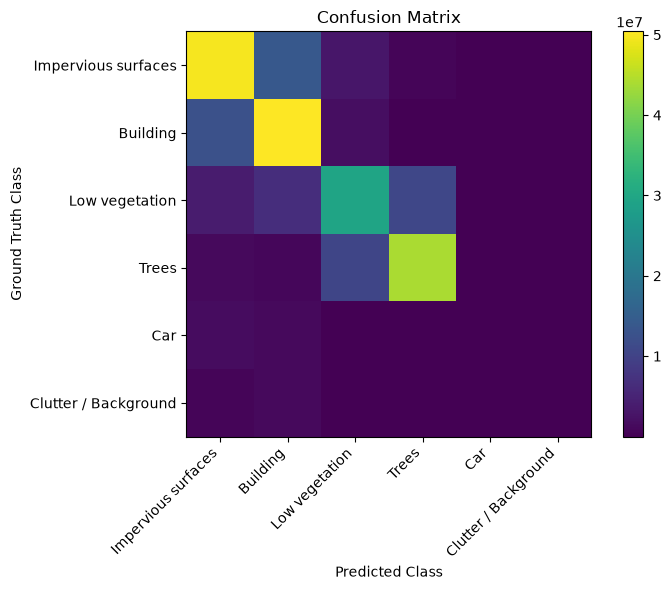

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(conf_matrix)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Ground Truth Class")
plt.title("Confusion Matrix")

plt.colorbar()
plt.tight_layout()
plt.show()

### Pixel Accuracy

Pixel Accuracy measures the proportion of correctly classified pixels over all pixels.

It is computed as:

$$
\text{Pixel Accuracy}
=
\frac{\sum_c TP_c}{\text{Total number of pixels}}
$$

In [ ]:
pixel_accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)

print(f"Pixel Accuracy: {pixel_accuracy:.4f}")
print(f"Pixel Accuracy: {pixel_accuracy * 100:.2f}%")

Pixel Accuracy: 0.7088
Pixel Accuracy: 70.88%


### Intersection over Union (IoU)

IoU measures the overlap between the predicted region and the ground-truth region for each class.

For a class $c$:

$$
IoU_c =
\frac{TP_c}
{TP_c + FP_c + FN_c}
$$

The **Mean IoU** is the average IoU across the six semantic classes.

In [ ]:
ious = []

for class_idx in range(len(class_names)):

    true_positive = conf_matrix[class_idx, class_idx]

    false_positive = (
        conf_matrix[:, class_idx].sum()
        - true_positive
    )

    false_negative = (
        conf_matrix[class_idx, :].sum()
        - true_positive
    )

    denominator = (
        true_positive
        + false_positive
        + false_negative
    )

    if denominator == 0:
        iou = np.nan
    else:
        iou = true_positive / denominator

    ious.append(iou)

mean_iou = np.nanmean(ious)

for class_name, iou in zip(class_names, ious):
    print(f"{class_name:<25} {iou * 100:.2f}%")

print(f"\nMean IoU: {mean_iou * 100:.2f}%")

Impervious surfaces       56.81%
Building                  56.57%
Low vegetation            44.62%
Trees                     64.25%
Car                       4.13%
Clutter / Background      5.86%

Mean IoU: 38.71%


### Evaluation Results

The final model achieves the following results on the test set:

| Metric | Result |
|---|---:|
| Pixel Accuracy | **70.88%** |
| Mean IoU | **38.71%** |
| Impervious surfaces IoU | 56.81% |
| Building IoU | 56.57% |
| Low vegetation IoU | 44.62% |
| Trees IoU | 64.25% |
| Car IoU | 4.13% |
| Clutter / Background IoU | 5.86% |

The model performs relatively well on the main classes, particularly **Trees (64.25% IoU)**, **Impervious surfaces (56.81%)**, and **Buildings (56.57%)**.

The **Car** and **Clutter / Background** classes remain challenging, with much lower IoU values. This indicates that the model has difficulty with classes that are less well represented in the training data.

Overall, the model reaches **70.88% Pixel Accuracy** and **38.71% Mean IoU** on the test set.

## 8. Qualitative Results

Quantitative metrics provide an overall measure of segmentation performance, but visual inspection is also important.

In this section, we visualize the model prediction on an unseen test image and compare it with the corresponding ground truth.

The visualization shows:

- the original aerial image,
- the predicted segmentation,
- the ground-truth segmentation.

### Full-Image Inference

The test image is processed patch by patch using the pre-trained Hypercolumns CNN.

The patch predictions are then reconstructed to obtain a full-resolution semantic segmentation map.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch


patch_size = 512
batch_size = 3
conversion = T.ToTensor()


def process_image(image):
    """
    Predict the semantic class for every pixel of a full aerial image.
    """

    img = image / 255.0

    output = np.zeros(
        (6, img.shape[0], img.shape[1])
    )

    batch = torch.zeros(
        (batch_size, 3, patch_size, patch_size)
    )

    batch_indices = []
    batch_number = 0

    for i in np.arange(0, img.shape[0], patch_size):

        iend = min(i + patch_size, img.shape[0])
        istart = iend - patch_size

        for j in np.arange(0, img.shape[1], patch_size):

            jend = min(j + patch_size, img.shape[1])
            jstart = jend - patch_size

            torch_image = conversion(
                img[istart:iend, jstart:jend, :]
            ).float()

            batch[batch_number] = torch_image
            batch_indices.append(
                [istart, iend, jstart, jend]
            )

            batch_number += 1

            if (
                batch_number == batch_size
                or (iend == img.shape[0] and jend == img.shape[1])
            ):

                input_batch = batch.to(device)

                with torch.no_grad():
                    predictions = network(input_batch)

                for output_num in range(batch_number):

                    istart, iend, jstart, jend = batch_indices[output_num]

                    output[
                        :,
                        istart:iend,
                        jstart:jend
                    ] = (
                        predictions[output_num]
                        .cpu()
                        .numpy()
                    )

                batch_number = 0
                batch_indices = []

    return np.argmax(output, axis=0)

### Class Visualization

The predicted class indices are converted to the same color representation used by the ground-truth maps.

In [ ]:
class_colors = np.array([
    [255, 255, 255],  # Impervious surfaces
    [0, 0, 255],      # Building
    [0, 255, 255],    # Low vegetation
    [0, 255, 0],      # Trees
    [255, 255, 0],    # Car
    [255, 0, 0]       # Clutter / Background
])


def convert_prediction(segmentation):
    return class_colors[segmentation]

In [ ]:
test_image_name = "top_mosaic_09cm_area2.tif"

image_path = os.path.join(
    "../data",
    "top",
    test_image_name
)

gt_path = os.path.join(
    "../data",
    "1CGT",
    test_image_name
)

image = io.imread(image_path)
ground_truth = io.imread(gt_path)

prediction = process_image(image)

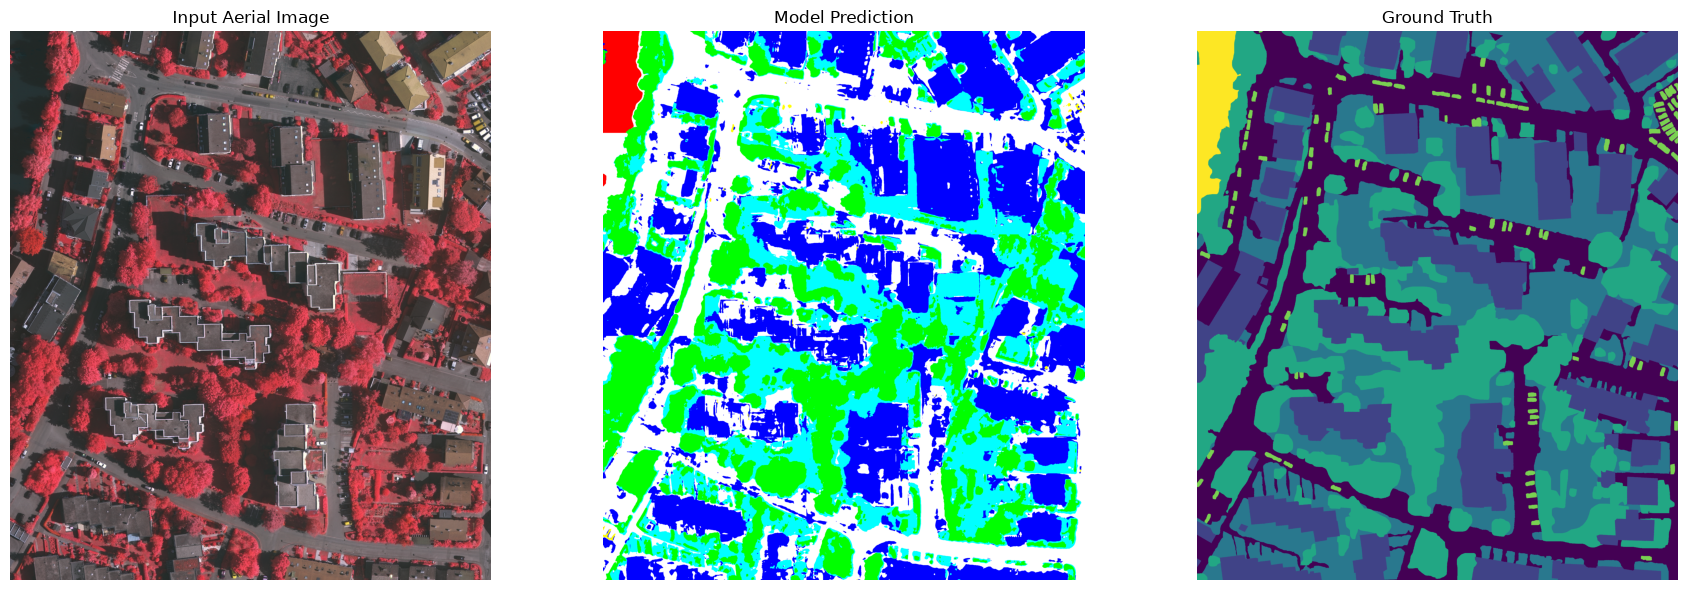

In [ ]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

axes[0].imshow(image)
axes[0].set_title("Input Aerial Image")
axes[0].axis("off")

axes[1].imshow(convert_prediction(prediction))
axes[1].set_title("Model Prediction")
axes[1].axis("off")

axes[2].imshow(ground_truth)
axes[2].set_title("Ground Truth")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Visual Analysis

The qualitative result shows that the model is able to recover the main spatial structures of the scene.

Large and visually distinctive regions such as **buildings, trees, and impervious surfaces** are generally better segmented.

Small objects such as **cars** remain more challenging, which is consistent with the lower IoU observed for this class in the quantitative evaluation.

## 9. Experiments

Two training experiments were conducted to study the effect of training duration on segmentation performance.

Both experiments used the same Hypercolumns CNN architecture and training setup. The main difference was the number of training epochs:

- **V1:** 2 epochs
- **V2:** 10 epochs

The results are compared below.

### Quantitative Comparison

| Metric | V1 — 2 Epochs | V2 — 10 Epochs |
|---|---:|---:|
| Pixel Accuracy | 62.53% | **70.88%** |
| Class 0 IoU | 51.36% | **56.81%** |
| Class 1 IoU | 35.54% | **56.57%** |
| Class 2 IoU | 31.79% | **44.62%** |
| Class 3 IoU | 60.73% | **64.25%** |
| Class 4 IoU | 0.00% | **4.13%** |
| Class 5 IoU | 0.00% | **5.86%** |
| **Mean IoU** | **29.90%** | **38.71%** |

### Experiment Analysis

Increasing the training duration from 2 to 10 epochs improved the overall segmentation performance.

Pixel Accuracy increased from **62.53% to 70.88%**, while Mean IoU increased from **29.90% to 38.71%**.

The improvement was particularly significant for **Class 1**, whose IoU increased from **35.54% to 56.57%**.

Classes 4 and 5 were not predicted in the 2-epoch experiment, while the 10-epoch model started to detect these classes, although their IoU remained low.

### Training and Validation Loss

The following curve shows the training and validation losses recorded during the 10-epoch experiment.

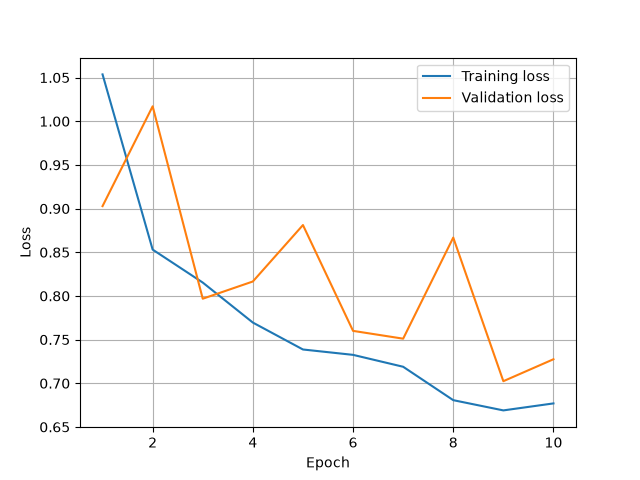

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename="../results/figures/training_validation_loss.png"
    )
)

### Interpretation

The experiments show that the initial 2-epoch training was not sufficient for the model to fully learn the segmentation task.

Training for 10 epochs improved both Pixel Accuracy and Mean IoU and allowed the model to start predicting the more difficult classes.

However, the low IoU values obtained for **Car** and **Clutter / Background** indicate that these classes remain challenging.

Possible future improvements include addressing class imbalance, applying stronger data augmentation, and evaluating more advanced segmentation architectures.

## 10. Conclusion

This project implemented a complete semantic segmentation pipeline for high-resolution remote sensing images using a Hypercolumns-based CNN and PyTorch.

The final model, trained for 10 epochs, achieved:

- **70.88% Pixel Accuracy**
- **38.71% Mean IoU**

The project involved the complete workflow from image preprocessing and patch extraction to model definition, training, evaluation, and qualitative analysis.

The results demonstrate that the model can successfully segment major urban classes, while smaller or less represented classes remain more challenging.

This project provided practical experience in **Computer Vision, semantic segmentation, PyTorch, CNN architectures, pixel-level evaluation, and remote sensing imagery**.